# Elicitation Robustness Check

Tests whether the declarative-evaluative gap persists across meaningfully different
elicitation strategies. If the gap holds across all five template types, it rules out
prompting artifacts as a confounder.

**Design:**
- 3 accessibility concepts (closed captions, color contrast, page title)
- 1 control concept (bicycle) — general knowledge baseline
- 5 template types (cloze, direct_question, instruction, evaluative, scenario)
- 3 models (Pythia 2.8B, Pythia 1B, GPT-2 Large)
- 40 max tokens, temperature 0, greedy decoding

**What we expect:**
- Pythia 2.8B: coherent completions across all template types for accessibility concepts
- Pythia 1B: fails accessibility concepts across all template types (gap is real, not a prompting artifact)
- GPT-2 Large: cross-architecture comparison
- Bicycle control: all models should handle this regardless of size

## Setup

In [1]:
import json
import torch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from transformer_lens import HookedTransformer
from pathlib import Path

In [2]:
# Check device
if torch.backends.mps.is_available():
    device = 'mps'
elif torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'
print(f'Using device: {device}')

Using device: mps


## Load Prompts

In [3]:
# Load prompts from JSONL
prompt_file = Path('../data/elicitation_control_prompts.jsonl')

all_prompts = []
with open(prompt_file) as f:
    for line in f:
        all_prompts.append(json.loads(line.strip()))

# Group by template type for per-section iteration
template_types = ['cloze', 'direct_question', 'instruction', 'evaluative', 'scenario']
concepts = ['closed captions', 'color contrast', 'page title', 'bicycle']

prompts_by_type = {}
for tt in template_types:
    prompts_by_type[tt] = [p for p in all_prompts if p['template_type'] == tt]

# Override JSONL max_tokens — 40 is enough to see coherence vs. flailing
MAX_TOKENS = 40

print(f'Loaded {len(all_prompts)} prompts')
print(f'Concepts: {concepts}')
print(f'Template types: {template_types}')
print(f'Max tokens: {MAX_TOKENS}')

Loaded 20 prompts
Concepts: ['closed captions', 'color contrast', 'page title', 'bicycle']
Template types: ['cloze', 'direct_question', 'instruction', 'evaluative', 'scenario']
Max tokens: 40


## Shared Utilities

Minimal helpers used across all model sections. No generation wrappers —
each section runs its own prompts inline. Completions are cached in a dict
so heatmaps and result collection don't re-run generation.

In [4]:
def get_token_entropy(model, text):
    """Mean per-token entropy of the model's predictions for a given text.
    Lower = more confident. Higher = more uncertain / flailing."""
    tokens = model.to_tokens(text)
    logits = model(tokens)
    probs = torch.nn.functional.softmax(logits[0, :-1, :], dim=-1)
    entropy = -(probs * torch.log2(probs + 1e-10)).sum(dim=-1)
    return entropy.mean().item()


def plot_heatmap(data, title, ylabel, cmap='RdYlGn_r', vmin=None, vmax=None):
    """Simple heatmap: concepts (rows) x template types (columns)."""
    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.imshow(data.values, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    
    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(data.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(data.index)
    
    # Annotate cells
    for i in range(len(data.index)):
        for j in range(len(data.columns)):
            val = data.values[i, j]
            ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=11,
                    color='white' if val > (data.values.max() + data.values.min()) / 2 else 'black')
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel(ylabel)
    plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()

## Pythia 2.8B

*Role: emergence threshold*

### Load Model

In [5]:
model = HookedTransformer.from_pretrained('pythia-2.8b', device=device)
print(f"Layers: {model.cfg.n_layers}")
print(f"Heads: {model.cfg.n_heads}")
print(f"Hidden size: {model.cfg.d_model}")
print(f"Params: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")

# Cache for completions — generated once, reused for heatmaps and results
completions_cache = {}

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model pythia-2.8b into HookedTransformer
Layers: 32
Heads: 32
Hidden size: 2560
Params: 2774.9M


### Cloze Prompts

In [6]:
for p in prompts_by_type['cloze']:
    output = model.generate(p['prompt'], max_new_tokens=MAX_TOKENS, temperature=0, verbose=False)
    completion = output[len(p['prompt']):]
    completions_cache[p['prompt_id']] = {'output': output, 'completion': completion}
    print(f"{p['concept']:16} | {completion[:100]}")

closed captions  |  text in a box at the bottom of the screen.

Closed captions display text in a box at the bottom of 
color contrast   |  it is a key factor in determining the quality of a printed image. In a color image, the colors of t
page title       |  the content of the page.

A page title is a short, descriptive phrase that is displayed in the brow
bicycle          |  transportation, recreation, and sport. The bicycle is a vehicle that is powered by a rider's muscul


### Direct Question Prompts

In [7]:
for p in prompts_by_type['direct_question']:
    output = model.generate(p['prompt'], max_new_tokens=MAX_TOKENS, temperature=0, verbose=False)
    completion = output[len(p['prompt']):]
    completions_cache[p['prompt_id']] = {'output': output, 'completion': completion}
    print(f"{p['concept']:16} | {completion[:100]}")

closed captions  | 

Closed captions are subtitles that are displayed on the screen when the video is played. They are 
color contrast   | 

Color contrast is the difference between the color of the background and the color of the foregrou
page title       | 

A page title is the text that appears in the browser's title bar. It is the first thing that a use
bicycle          | 

A bicycle is a vehicle that uses a wheel to move. It is a type of vehicle that is powered by the m


### Instruction Prompts

In [8]:
for p in prompts_by_type['instruction']:
    output = model.generate(p['prompt'], max_new_tokens=MAX_TOKENS, temperature=0, verbose=False)
    completion = output[len(p['prompt']):]
    completions_cache[p['prompt_id']] = {'output': output, 'completion': completion}
    print(f"{p['concept']:16} | {completion[:100]}")

closed captions  | 

I'm working on a project that requires a lot of closed captions. I've been told that I need to exp
color contrast   | 

I'm a web developer and I'm trying to explain color contrast to a web developer. I've been trying 
page title       | 

I'm a web developer and I'm trying to explain to a client why their site has a page title of "Home
bicycle          | 

I’m a web developer and I’m looking to buy a bicycle. I’ve been looking at the different models an


### Evaluative Prompts

In [9]:
for p in prompts_by_type['evaluative']:
    output = model.generate(p['prompt'], max_new_tokens=MAX_TOKENS, temperature=0, verbose=False)
    completion = output[len(p['prompt']):]
    completions_cache[p['prompt_id']] = {'output': output, 'completion': completion}
    print(f"{p['concept']:16} | {completion[:100]}")

closed captions  |  the video is not in English.

Please contact us if you need a video in a different language.

A vid
color contrast   |  it is not in the same color range as the background.

Text with high color contrast is not accessib
page title       |  the user cannot determine what the page is about.

A web page without a title is not accessible bec
bicycle          |  it is not designed to stop.

A bicycle without brakes is not safe because it is not designed to sto


### Scenario Prompts

In [10]:
for p in prompts_by_type['scenario']:
    output = model.generate(p['prompt'], max_new_tokens=MAX_TOKENS, temperature=0, verbose=False)
    completion = output[len(p['prompt']):]
    completions_cache[p['prompt_id']] = {'output': output, 'completion': completion}
    print(f"{p['concept']:16} | {completion[:100]}")

closed captions  |  cannot understand the video. The user can use a screen reader to read the video. The screen reader 
color contrast   |  is able to see the text on the website, but is unable to read the text. The user is able to see the
page title       |  is then presented with a title bar and a list of links. The user then selects a link and is present
bicycle          |  is at risk of serious injury.

The child is wearing a helmet, but the helmet is not properly fitted


### Completion Length Heatmap

Completion length as a rough proxy for engagement with the concept.
Coherent models produce consistent, appropriately-sized completions.
Models below threshold tend to either truncate or ramble incoherently.

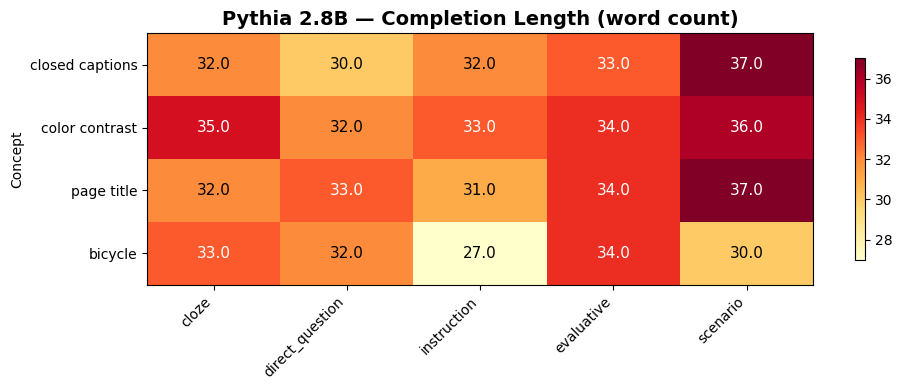

                 cloze  direct_question  instruction  evaluative  scenario
closed captions     32               30           32          33        37
color contrast      35               32           33          34        36
page title          32               33           31          34        37
bicycle             33               32           27          34        30


In [11]:
# Build length data from cache
length_data = {}
for p in all_prompts:
    completion = completions_cache[p['prompt_id']]['completion']
    length_data[(p['concept'], p['template_type'])] = len(completion.split())

length_df = pd.DataFrame(
    [[length_data.get((c, t), 0) for t in template_types] for c in concepts],
    index=concepts,
    columns=template_types
)

plot_heatmap(length_df, 'Pythia 2.8B — Completion Length (word count)', 'Concept', cmap='YlOrRd')
print(length_df.to_string())

### Token Entropy Heatmap

Mean per-token entropy of the model's output distribution across the full completion.
Lower entropy = confident predictions. Higher = uncertain / flailing.

If the model has genuinely bound the accessibility concept, entropy should be
comparably low to the bicycle control across all template types.

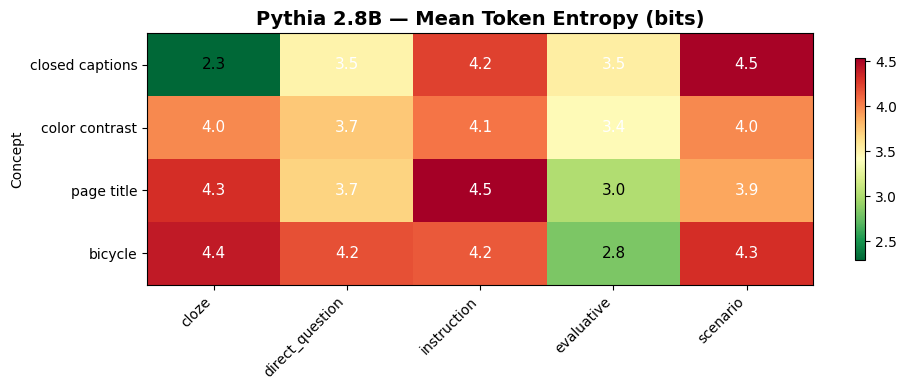

                    cloze  direct_question  instruction  evaluative  scenario
closed captions  2.297973         3.502537     4.243703    3.531092  4.509604
color contrast   3.987583         3.743551     4.054010    3.444076  3.986344
page title       4.317872         3.691142     4.533373    3.022651  3.885067
bicycle          4.403952         4.192582     4.151751    2.830256  4.319682


In [12]:
# Compute entropy from cached outputs (no re-generation, but does need a forward pass for logits)
entropy_data = {}
for p in all_prompts:
    output = completions_cache[p['prompt_id']]['output']
    entropy_data[(p['concept'], p['template_type'])] = get_token_entropy(model, output)

entropy_df = pd.DataFrame(
    [[entropy_data.get((c, t), 0) for t in template_types] for c in concepts],
    index=concepts,
    columns=template_types
)

plot_heatmap(entropy_df, 'Pythia 2.8B — Mean Token Entropy (bits)', 'Concept', cmap='RdYlGn_r')
print(entropy_df.to_string())

### Save Results

In [13]:
# Build DataFrame from cache — no re-generation
model_results = []
for p in all_prompts:
    cached = completions_cache[p['prompt_id']]
    model_results.append({
        'model': 'pythia-2.8b',
        'concept': p['concept'],
        'template_type': p['template_type'],
        'prompt_id': p['prompt_id'],
        'prompt': p['prompt'],
        'completion': cached['completion'],
        'word_count': len(cached['completion'].split()),
        'entropy': entropy_data[(p['concept'], p['template_type'])]
    })

df_pythia_2_8b = pd.DataFrame(model_results)
print(f"Collected {len(model_results)} results for Pythia 2.8B")

Collected 20 results for Pythia 2.8B


### Delete Model & Clear Cache

In [14]:
import gc
del model
del completions_cache
gc.collect()
if device == 'mps':
    torch.mps.empty_cache()
elif device == 'cuda':
    torch.cuda.empty_cache()
print("Memory cleared")

Memory cleared


## Pythia 1B

*Role: predicted dead zone*

### Load Model

In [15]:
model = HookedTransformer.from_pretrained('pythia-1b', device=device)
print(f"Layers: {model.cfg.n_layers}")
print(f"Heads: {model.cfg.n_heads}")
print(f"Hidden size: {model.cfg.d_model}")
print(f"Params: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")

# Cache for completions — generated once, reused for heatmaps and results
completions_cache = {}

Loaded pretrained model pythia-1b into HookedTransformer
Layers: 16
Heads: 8
Hidden size: 2048
Params: 1011.7M


### Cloze Prompts

In [16]:
for p in prompts_by_type['cloze']:
    output = model.generate(p['prompt'], max_new_tokens=MAX_TOKENS, temperature=0, verbose=False)
    completion = output[len(p['prompt']):]
    completions_cache[p['prompt_id']] = {'output': output, 'completion': completion}
    print(f"{p['concept']:16} | {completion[:100]}")

closed captions  |  on a computer screen are typically used to provide a visual representation of a video sequence. The
color contrast   |  it is the basis for many of the visual effects in computer graphics. The color contrast of a scene 
page title       |  the content of the page. A title is a short description of the page content. A title is usually a s
bicycle          |  transportation, and is generally provided with a front wheel and a rear wheel. The front wheel is r


### Direct Question Prompts

In [17]:
for p in prompts_by_type['direct_question']:
    output = model.generate(p['prompt'], max_new_tokens=MAX_TOKENS, temperature=0, verbose=False)
    completion = output[len(p['prompt']):]
    completions_cache[p['prompt_id']] = {'output': output, 'completion': completion}
    print(f"{p['concept']:16} | {completion[:100]}")

closed captions  | 

Closed captions are a new feature in the Google Translate app. They are a way to add captions to y
color contrast   | 

Color contrast is the difference between the colors of two objects.

For example, if you see a red
page title       | 

A page title is a short, descriptive name for a page in a website. It is usually a short, descript
bicycle          | 

A bicycle is a wheeled vehicle that is powered by a motor. The motor is usually a gasoline-powered


### Instruction Prompts

In [18]:
for p in prompts_by_type['instruction']:
    output = model.generate(p['prompt'], max_new_tokens=MAX_TOKENS, temperature=0, verbose=False)
    completion = output[len(p['prompt']):]
    completions_cache[p['prompt_id']] = {'output': output, 'completion': completion}
    print(f"{p['concept']:16} | {completion[:100]}")

closed captions  | 

I have a client who is a web developer. He is a very good developer, but he is not very good at ex
color contrast   | 

I have a client who is a web developer. He is a very good developer, but he is not very good at ex
page title       | 

I have a page that is supposed to be a simple list of items. The page title is supposed to be a li
bicycle          | 

I’ve been working on a project for a client that is a bit different from the usual web development


### Evaluative Prompts

In [19]:
for p in prompts_by_type['evaluative']:
    output = model.generate(p['prompt'], max_new_tokens=MAX_TOKENS, temperature=0, verbose=False)
    completion = output[len(p['prompt']):]
    completions_cache[p['prompt_id']] = {'output': output, 'completion': completion}
    print(f"{p['concept']:16} | {completion[:100]}")

closed captions  |  the video is not available in the video player.

A video without closed captions is not accessible 
color contrast   |  of the low color contrast.

Text with high color contrast is not accessible because of the high col
page title       |  the title is not available.

A web page without a title is not accessible because the title is not 
bicycle          |  it is not safe to ride.

The bicycle without brakes is not safe because it is not safe to ride.

Th


### Scenario Prompts

In [20]:
for p in prompts_by_type['scenario']:
    output = model.generate(p['prompt'], max_new_tokens=MAX_TOKENS, temperature=0, verbose=False)
    completion = output[len(p['prompt']):]
    completions_cache[p['prompt_id']] = {'output': output, 'completion': completion}
    print(f"{p['concept']:16} | {completion[:100]}")

closed captions  |  can hear the audio of the video.

A deaf user is watching a video on a website. Without closed capt
color contrast   |  is unable to see the website's content. The user is unable to see the website's content. The user i
page title       |  is presented with a list of options. The user selects one of the options and the screen reader disp
bicycle          |  is at risk of being struck by a car.

A child is riding a bicycle on a busy street. Without a helme


### Completion Length Heatmap

Completion length as a rough proxy for engagement with the concept.
Coherent models produce consistent, appropriately-sized completions.
Models below threshold tend to either truncate or ramble incoherently.

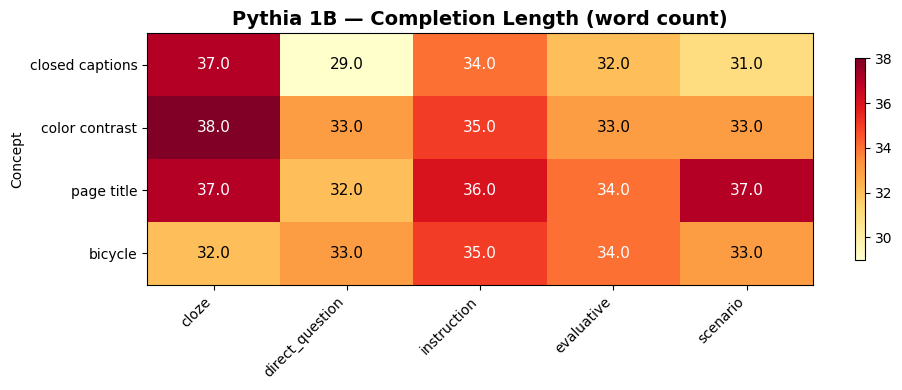

                 cloze  direct_question  instruction  evaluative  scenario
closed captions     37               29           34          32        31
color contrast      38               33           35          33        33
page title          37               32           36          34        37
bicycle             32               33           35          34        33


In [21]:
# Build length data from cache
length_data = {}
for p in all_prompts:
    completion = completions_cache[p['prompt_id']]['completion']
    length_data[(p['concept'], p['template_type'])] = len(completion.split())

length_df = pd.DataFrame(
    [[length_data.get((c, t), 0) for t in template_types] for c in concepts],
    index=concepts,
    columns=template_types
)

plot_heatmap(length_df, 'Pythia 1B — Completion Length (word count)', 'Concept', cmap='YlOrRd')
print(length_df.to_string())

### Token Entropy Heatmap

Mean per-token entropy of the model's output distribution across the full completion.
Lower entropy = confident predictions. Higher = uncertain / flailing.

If the model has genuinely bound the accessibility concept, entropy should be
comparably low to the bicycle control across all template types.

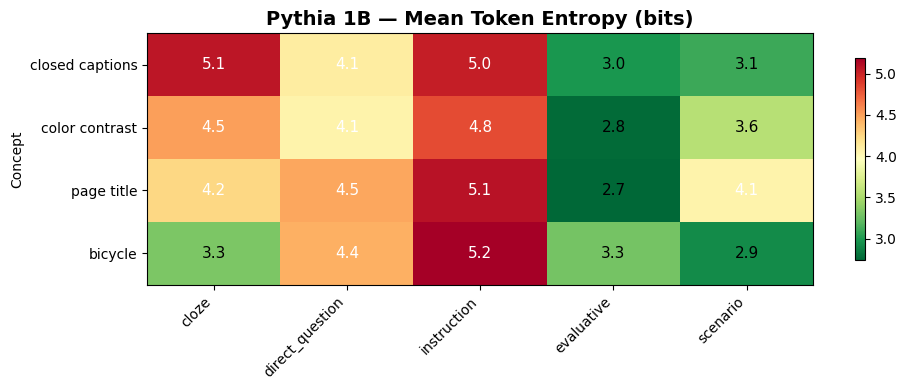

                    cloze  direct_question  instruction  evaluative  scenario
closed captions  5.065367         4.099857     5.022790    2.992900  3.101779
color contrast   4.501224         4.052757     4.827348    2.772746  3.564046
page title       4.244547         4.469708     5.081560    2.746461  4.055648
bicycle          3.318882         4.434602     5.182450    3.290060  2.927946


In [22]:
# Compute entropy from cached outputs (no re-generation, but does need a forward pass for logits)
entropy_data = {}
for p in all_prompts:
    output = completions_cache[p['prompt_id']]['output']
    entropy_data[(p['concept'], p['template_type'])] = get_token_entropy(model, output)

entropy_df = pd.DataFrame(
    [[entropy_data.get((c, t), 0) for t in template_types] for c in concepts],
    index=concepts,
    columns=template_types
)

plot_heatmap(entropy_df, 'Pythia 1B — Mean Token Entropy (bits)', 'Concept', cmap='RdYlGn_r')
print(entropy_df.to_string())

### Save Results

In [23]:
# Build DataFrame from cache — no re-generation
model_results = []
for p in all_prompts:
    cached = completions_cache[p['prompt_id']]
    model_results.append({
        'model': 'pythia-1b',
        'concept': p['concept'],
        'template_type': p['template_type'],
        'prompt_id': p['prompt_id'],
        'prompt': p['prompt'],
        'completion': cached['completion'],
        'word_count': len(cached['completion'].split()),
        'entropy': entropy_data[(p['concept'], p['template_type'])]
    })

df_pythia_1b = pd.DataFrame(model_results)
print(f"Collected {len(model_results)} results for Pythia 1B")

Collected 20 results for Pythia 1B


### Delete Model & Clear Cache

In [24]:
import gc
del model
del completions_cache
gc.collect()
if device == 'mps':
    torch.mps.empty_cache()
elif device == 'cuda':
    torch.cuda.empty_cache()
print("Memory cleared")

Memory cleared


## GPT-2 Large

*Role: cross-architecture check*

### Load Model

In [25]:
model = HookedTransformer.from_pretrained('gpt2-large', device=device)
print(f"Layers: {model.cfg.n_layers}")
print(f"Heads: {model.cfg.n_heads}")
print(f"Hidden size: {model.cfg.d_model}")
print(f"Params: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")

# Cache for completions — generated once, reused for heatmaps and results
completions_cache = {}

Loaded pretrained model gpt2-large into HookedTransformer
Layers: 36
Heads: 20
Hidden size: 1280
Params: 838.2M


### Cloze Prompts

In [26]:
for p in prompts_by_type['cloze']:
    output = model.generate(p['prompt'], max_new_tokens=MAX_TOKENS, temperature=0, verbose=False)
    completion = output[len(p['prompt']):]
    completions_cache[p['prompt_id']] = {'output': output, 'completion': completion}
    print(f"{p['concept']:16} | {completion[:100]}")

closed captions  |  the words in the original language, while the subtitles display the words in the target language.


color contrast   |  it allows you to see the difference between two colors.

The color contrast of a color is the diffe
page title       |  the content of the page.

A page title can be used to describe the content of a page.

A page title
bicycle          |  transportation in the city of San Francisco, California, U.S., on Friday, May 19, 2017. The city is


### Direct Question Prompts

In [27]:
for p in prompts_by_type['direct_question']:
    output = model.generate(p['prompt'], max_new_tokens=MAX_TOKENS, temperature=0, verbose=False)
    completion = output[len(p['prompt']):]
    completions_cache[p['prompt_id']] = {'output': output, 'completion': completion}
    print(f"{p['concept']:16} | {completion[:100]}")

closed captions  | 

Closed captions are a feature of the video player that allows you to watch the video without havin
color contrast   | 

Color contrast is the difference between two colors. It is the difference between the two colors t
page title       | 

A page title is a short description of the page. It is usually a short sentence or two, but can be
bicycle          | 

A bicycle is a vehicle that is propelled by human power. It is a vehicle that is propelled by huma


### Instruction Prompts

In [28]:
for p in prompts_by_type['instruction']:
    output = model.generate(p['prompt'], max_new_tokens=MAX_TOKENS, temperature=0, verbose=False)
    completion = output[len(p['prompt']):]
    completions_cache[p['prompt_id']] = {'output': output, 'completion': completion}
    print(f"{p['concept']:16} | {completion[:100]}")

closed captions  | 

I've been working on a web app for a few months now. I've been using the HTML5 Canvas API to creat
color contrast   | 

Color contrast is the ability to distinguish between two colors. It's a fundamental concept in col
page title       | 

A web developer can't help but get confused when they're trying to explain a page title to a web d
bicycle          | 

Bicycle design is a complex topic. It's not just about the wheels, but the frame, the seat, the ha


### Evaluative Prompts

In [29]:
for p in prompts_by_type['evaluative']:
    output = model.generate(p['prompt'], max_new_tokens=MAX_TOKENS, temperature=0, verbose=False)
    completion = output[len(p['prompt']):]
    completions_cache[p['prompt_id']] = {'output': output, 'completion': completion}
    print(f"{p['concept']:16} | {completion[:100]}")

closed captions  |  it does not meet the video player's video quality requirements.

Open captioning is available for t
color contrast   |  it is not a color.

Text with low color contrast is not accessible because it is not a color.

Text
page title       |  it is not a web page.

A web page without a title is not accessible because it is not a web page.


bicycle          |  it is not a vehicle.

A bicycle without brakes is not safe because it is not a vehicle.

A bicycle 


### Scenario Prompts

In [30]:
for p in prompts_by_type['scenario']:
    output = model.generate(p['prompt'], max_new_tokens=MAX_TOKENS, temperature=0, verbose=False)
    completion = output[len(p['prompt']):]
    completions_cache[p['prompt_id']] = {'output': output, 'completion': completion}
    print(f"{p['concept']:16} | {completion[:100]}")

closed captions  |  can't understand what is being said.

A deaf user is watching a video on a website. Without closed 
color contrast   |  is unable to distinguish between the text and the background.

The user is unable to distinguish be
page title       |  is presented with a blank screen. The user is then asked to type in the title of the page. The scre
bicycle          |  is at risk of serious injury.

A child is riding a bicycle on a busy street. Without a helmet, the 


### Completion Length Heatmap

Completion length as a rough proxy for engagement with the concept.
Coherent models produce consistent, appropriately-sized completions.
Models below threshold tend to either truncate or ramble incoherently.

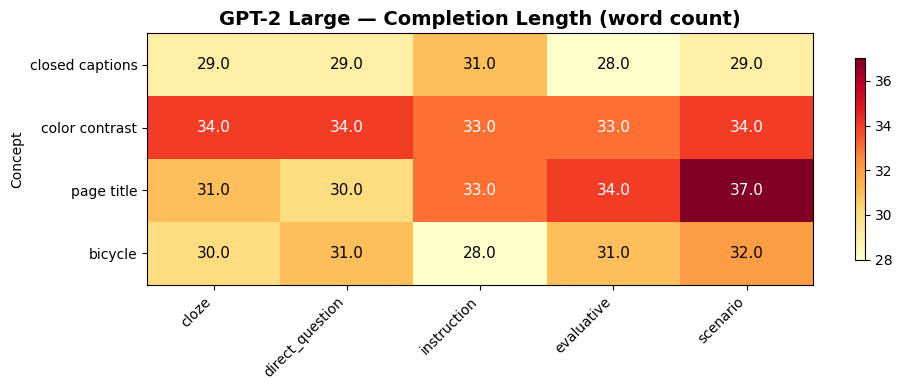

                 cloze  direct_question  instruction  evaluative  scenario
closed captions     29               29           31          28        29
color contrast      34               34           33          33        34
page title          31               30           33          34        37
bicycle             30               31           28          31        32


In [31]:
# Build length data from cache
length_data = {}
for p in all_prompts:
    completion = completions_cache[p['prompt_id']]['completion']
    length_data[(p['concept'], p['template_type'])] = len(completion.split())

length_df = pd.DataFrame(
    [[length_data.get((c, t), 0) for t in template_types] for c in concepts],
    index=concepts,
    columns=template_types
)

plot_heatmap(length_df, 'GPT-2 Large — Completion Length (word count)', 'Concept', cmap='YlOrRd')
print(length_df.to_string())

### Token Entropy Heatmap

Mean per-token entropy of the model's output distribution across the full completion.
Lower entropy = confident predictions. Higher = uncertain / flailing.

If the model has genuinely bound the accessibility concept, entropy should be
comparably low to the bicycle control across all template types.

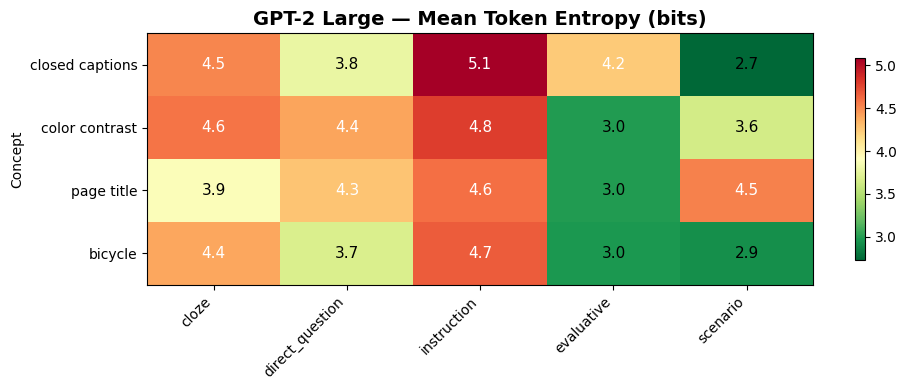

                    cloze  direct_question  instruction  evaluative  scenario
closed captions  4.512342         3.785524     5.079416    4.245103  2.733661
color contrast   4.576593         4.409851     4.795280    2.990777  3.643859
page title       3.887936         4.269812     4.596246    2.998055  4.531821
bicycle          4.392694         3.685957     4.672662    2.978082  2.926327


In [32]:
# Compute entropy from cached outputs (no re-generation, but does need a forward pass for logits)
entropy_data = {}
for p in all_prompts:
    output = completions_cache[p['prompt_id']]['output']
    entropy_data[(p['concept'], p['template_type'])] = get_token_entropy(model, output)

entropy_df = pd.DataFrame(
    [[entropy_data.get((c, t), 0) for t in template_types] for c in concepts],
    index=concepts,
    columns=template_types
)

plot_heatmap(entropy_df, 'GPT-2 Large — Mean Token Entropy (bits)', 'Concept', cmap='RdYlGn_r')
print(entropy_df.to_string())

### Save Results

In [34]:
# Build DataFrame from cache — no re-generation
model_results = []
for p in all_prompts:
    cached = completions_cache[p['prompt_id']]
    model_results.append({
        'model': 'gpt2-large',
        'concept': p['concept'],
        'template_type': p['template_type'],
        'prompt_id': p['prompt_id'],
        'prompt': p['prompt'],
        'completion': cached['completion'],
        'word_count': len(cached['completion'].split()),
        'entropy': entropy_data[(p['concept'], p['template_type'])]
    })

df_gpt2_large = pd.DataFrame(model_results)
print(f"Collected {len(model_results)} results for GPT-2 Large")

Collected 20 results for GPT-2 Large


### Delete Model & Clear Cache

In [35]:
import gc
del model
del completions_cache
gc.collect()
if device == 'mps':
    torch.mps.empty_cache()
elif device == 'cuda':
    torch.cuda.empty_cache()
print("Memory cleared")

Memory cleared


## Combined Analysis

Merge all model results and generate cross-model comparison visualizations.

In [36]:
# Combine all model DataFrames
df = pd.concat([df_pythia_2_8b, df_pythia_1b, df_gpt2_large], ignore_index=True)
df.to_csv('../results/elicitation_robustness_raw.csv', index=False)
print(f'Saved {len(df)} total results')
df.head()

Saved 60 total results


,model,concept,template_type,prompt_id,prompt,completion,word_count,entropy
0,pythia-2.8b,closed captions,cloze,cloze_cc_001,Closed captions display,text in a box at the bottom of the screen.\n\...,32,2.297973
1,pythia-2.8b,color contrast,cloze,cloze_contrast_001,Color contrast is important because,it is a key factor in determining the quality...,35,3.987583
2,pythia-2.8b,page title,cloze,cloze_title_001,A page title describes,the content of the page.\n\nA page title is a...,32,4.317872
3,pythia-2.8b,closed captions,direct_question,direct_cc_001,What are closed captions?,\n\nClosed captions are subtitles that are dis...,30,3.502537
4,pythia-2.8b,color contrast,direct_question,direct_contrast_001,What is color contrast?,\n\nColor contrast is the difference between t...,32,3.743551


### Cross-Model Entropy Comparison

Side-by-side entropy heatmaps for all three models.
This is the key visualization: if the gap is real, accessibility rows
should show high entropy for Pythia 1B but low entropy for Pythia 2.8B,
while the bicycle control stays low across all models.

/var/folders/yh/xk6gjqjx7hn5f6v0rd14jj8h0000gn/T/ipykernel_26207/1557201890.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


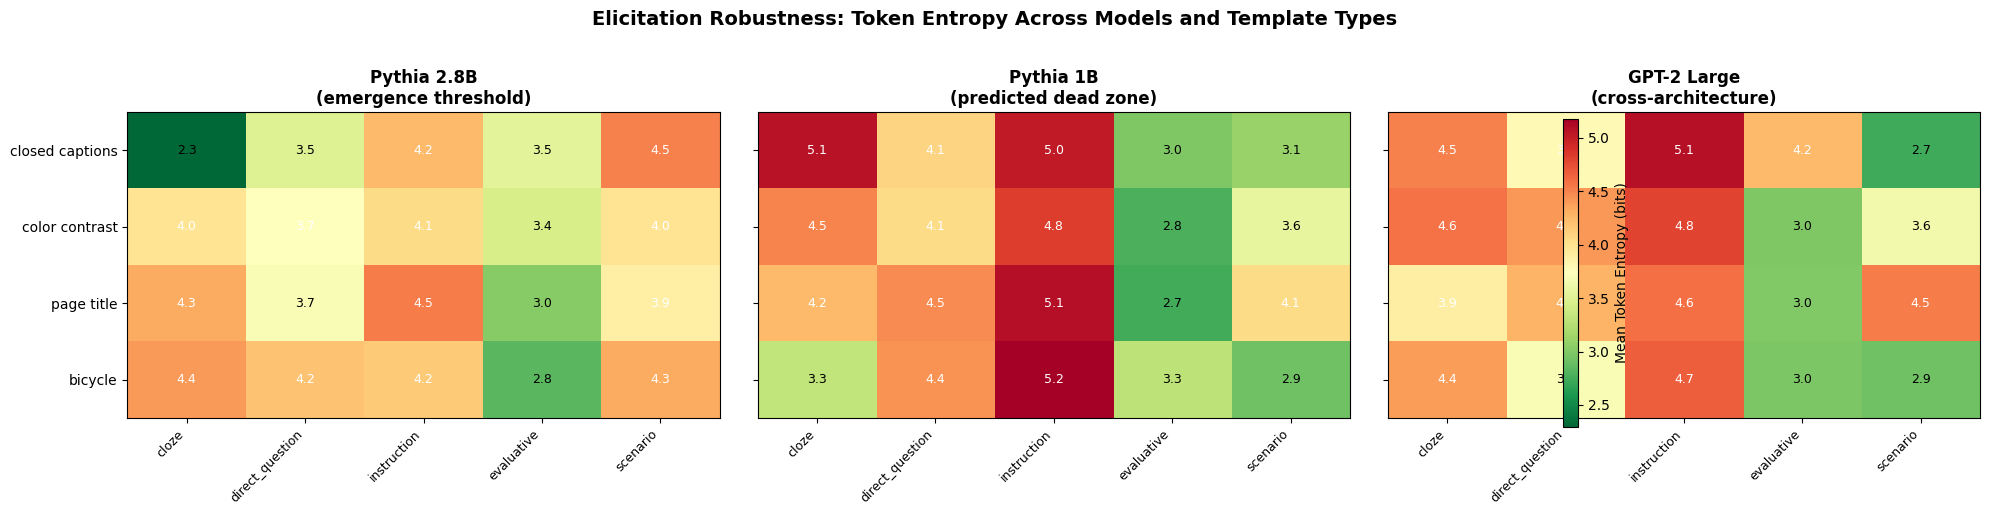

Saved to ../figures/elicitation_robustness_entropy.png


In [37]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

for idx, (model_name, model_label) in enumerate([
    ('pythia-2.8b', 'Pythia 2.8B\n(emergence threshold)'),
    ('pythia-1b', 'Pythia 1B\n(predicted dead zone)'),
    ('gpt2-large', 'GPT-2 Large\n(cross-architecture)')
]):
    model_df = df[df['model'] == model_name]
    
    pivot = model_df.pivot_table(
        values='entropy', index='concept', columns='template_type'
    )
    pivot = pivot.reindex(index=concepts, columns=template_types)
    
    ax = axes[idx]
    im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto', vmin=df['entropy'].min(), vmax=df['entropy'].max())
    
    ax.set_xticks(range(len(template_types)))
    ax.set_xticklabels(template_types, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(concepts)))
    if idx == 0:
        ax.set_yticklabels(concepts, fontsize=10)
    ax.set_title(model_label, fontsize=12, fontweight='bold')
    
    for i in range(len(concepts)):
        for j in range(len(template_types)):
            val = pivot.values[i, j]
            ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=9,
                    color='white' if val > (df['entropy'].max() + df['entropy'].min()) / 2 else 'black')

plt.colorbar(im, ax=axes, shrink=0.8, label='Mean Token Entropy (bits)')
plt.suptitle('Elicitation Robustness: Token Entropy Across Models and Template Types', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/elicitation_robustness_entropy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to ../figures/elicitation_robustness_entropy.png")

### Cross-Model Completion Length Comparison

/var/folders/yh/xk6gjqjx7hn5f6v0rd14jj8h0000gn/T/ipykernel_26207/883278710.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


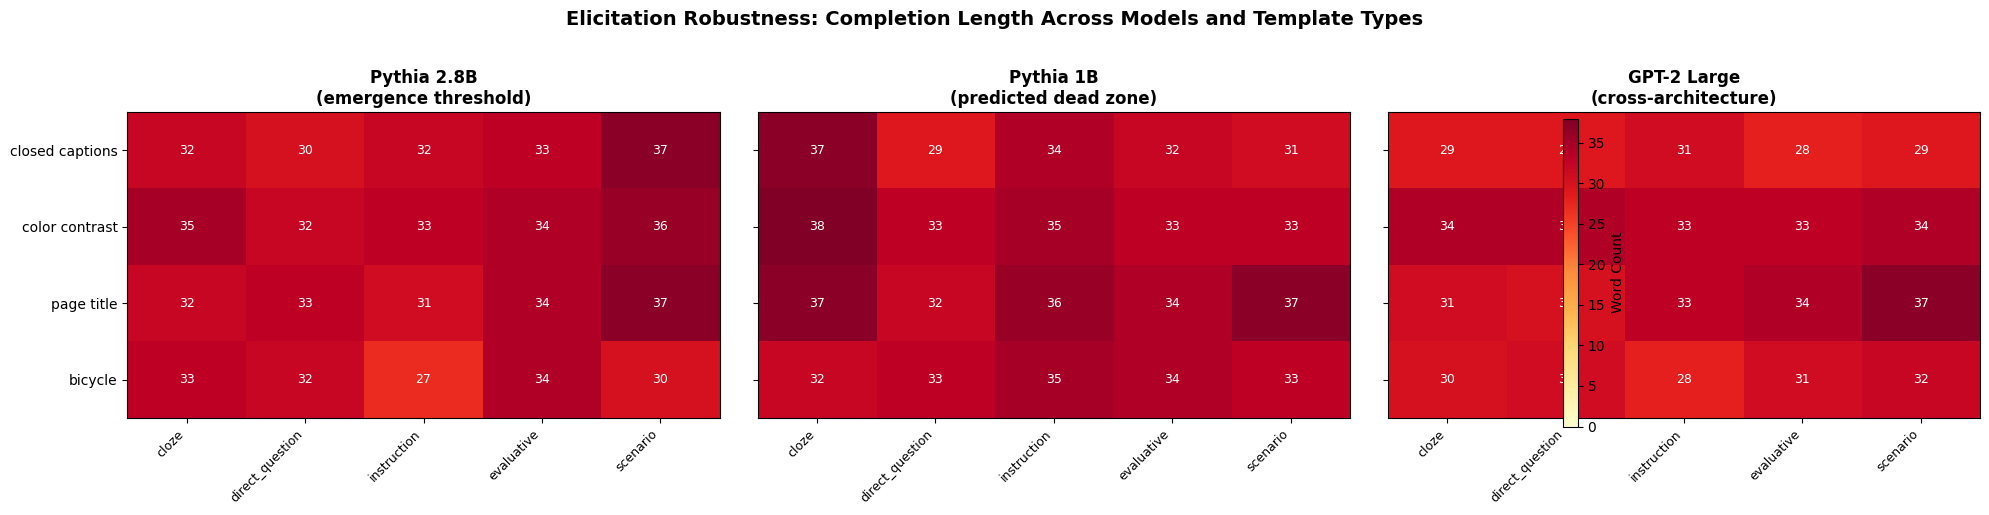

Saved to ../figures/elicitation_robustness_length.png


In [38]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

for idx, (model_name, model_label) in enumerate([
    ('pythia-2.8b', 'Pythia 2.8B\n(emergence threshold)'),
    ('pythia-1b', 'Pythia 1B\n(predicted dead zone)'),
    ('gpt2-large', 'GPT-2 Large\n(cross-architecture)')
]):
    model_df = df[df['model'] == model_name]
    
    pivot = model_df.pivot_table(
        values='word_count', index='concept', columns='template_type'
    )
    pivot = pivot.reindex(index=concepts, columns=template_types)
    
    ax = axes[idx]
    im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=df['word_count'].max())
    
    ax.set_xticks(range(len(template_types)))
    ax.set_xticklabels(template_types, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(concepts)))
    if idx == 0:
        ax.set_yticklabels(concepts, fontsize=10)
    ax.set_title(model_label, fontsize=12, fontweight='bold')
    
    for i in range(len(concepts)):
        for j in range(len(template_types)):
            val = pivot.values[i, j]
            ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=9,
                    color='white' if val > df['word_count'].max() * 0.6 else 'black')

plt.colorbar(im, ax=axes, shrink=0.8, label='Word Count')
plt.suptitle('Elicitation Robustness: Completion Length Across Models and Template Types', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/elicitation_robustness_length.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to ../figures/elicitation_robustness_length.png")